In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 选择系统中已有的中文字体（从你的字体列表中选一个）
font_path = "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc"  # 文泉驿微米黑
# 或思源黑体：font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

# 全局设置字体
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# 验证配置是否生效
print("当前字体配置：", plt.rcParams["font.family"])

当前字体配置： ['WenQuanYi Zen Hei']


Events after ROI: 2568152


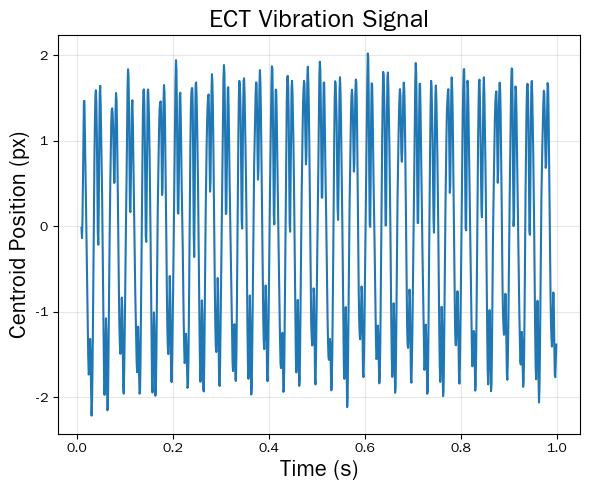

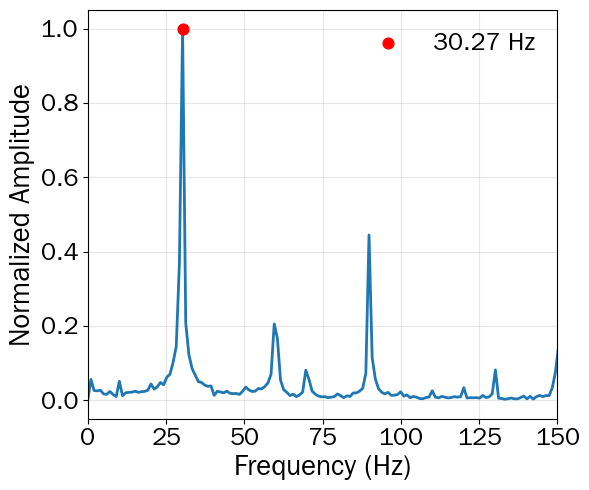


========== ECT Vibration Result ==========
Auxiliary Phase Frequency : 43.890 Hz
Final FFT Dominant Frequency : 30.272 Hz
Estimated Amplitude : 2.119 px


In [18]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter1d

# =========================================================
# 1. 读取事件数据
# =========================================================
def load_events(file_path):
    with h5py.File(file_path, 'r') as f:
        if 'CD' in f and 'events' in f['CD']:
            e = f['CD/events'][:]

            return {
                'x': e['x'].astype(float),
                'y': e['y'].astype(float),
                't': e['t'].astype(float) * 1e-6,   # us → s
                'p': e['p'].astype(float)
            }

    raise ValueError("无效的 HDF5 文件结构")


# =========================================================
# 2. ROI + 时间截取
# =========================================================
def select_roi(events, roi, t_range):

    x, y, t = events['x'], events['y'], events['t']

    rx0, rx1, ry0, ry1 = roi
    t0, t1 = t_range

    m = (
        (x >= rx0) & (x <= rx1) &
        (y >= ry0) & (y <= ry1) &
        (t >= t0) & (t <= t1)
    )

    return {
        'x': x[m],
        'y': y[m],
        't': t[m],
        'p': events['p'][m]
    }


# =========================================================
# 3. ECT：事件质心轨迹
# =========================================================
def event_centroid_tracking(events,
                             dt=0.001,
                             min_events=30,
                             smooth_sigma=1.0):

    t = events['t']
    y = events['y']

    t0 = t.min()
    t1 = t.max()

    centers = []
    times = []

    n_bins = int((t1 - t0) // dt)

    for i in range(n_bins):

        ta = t0 + i * dt
        tb = ta + dt

        m = (t >= ta) & (t < tb)

        # 事件太少则跳过
        if np.sum(m) < min_events:
            continue

        # =================================================
        # ECT核心：
        # 直接对事件坐标求质心
        # =================================================
        yc = np.mean(y[m])

        centers.append(yc)
        times.append((ta + tb) / 2)

    centers = np.array(centers)
    times = np.array(times)

    # 去 DC
    centers -= np.mean(centers)

    # 平滑
    centers = gaussian_filter1d(centers, sigma=smooth_sigma)

    return times, centers


# =========================================================
# 4. Phase + FFT 振动分析
# =========================================================
def phase_with_fft(times,
                   signal,
                   show_spectrum=True,
                   save_path="ect_fft.png"):

    # -----------------------------------------------------
    # 参数
    # -----------------------------------------------------
    grid_alpha = 0.3
    label_fontsize = 20
    tick_fontsize = 18

    # -----------------------------------------------------
    # 去均值
    # -----------------------------------------------------
    signal = signal - np.mean(signal)

    # =====================================================
    # Hilbert 相位分析（辅助）
    # =====================================================
    analytic = hilbert(signal)

    phase = np.unwrap(np.angle(analytic))

    inst_freq = np.diff(phase) / (
        2 * np.pi * np.diff(times)
    )

    f_phase = np.median(inst_freq)

    # =====================================================
    # FFT 主频分析（最终结果）
    # =====================================================
    fs = 1.0 / np.mean(np.diff(times))

    N = len(signal)

    freqs = np.fft.rfftfreq(N, d=1/fs)

    spectrum = np.abs(np.fft.rfft(signal))

    spectrum /= spectrum.max() + 1e-12

    idx = np.argmax(spectrum)

    f_fft = freqs[idx]

    amp_fft = spectrum[idx]

    # =====================================================
    # 可视化频谱
    # =====================================================
    if show_spectrum:

        plt.figure(figsize=(6, 5))

        plt.plot(freqs, spectrum, lw=2)

        plt.scatter(
            f_fft,
            amp_fft,
            color='r',
            s=60,
            zorder=3,
            label=f"{f_fft:.2f} Hz"
        )

        plt.xlabel(
            "Frequency (Hz)",
            fontsize=label_fontsize
        )

        plt.ylabel(
            "Normalized Amplitude",
            fontsize=label_fontsize
        )

        plt.xlim(0, 150)

        plt.legend(
            frameon=False,
            fontsize=tick_fontsize
        )

        plt.grid(alpha=grid_alpha)

        plt.tick_params(
            axis='both',
            labelsize=tick_fontsize
        )

        plt.tight_layout()

        # plt.savefig(save_path,
        #             dpi=300,
        #             bbox_inches='tight')

        plt.show()

    return f_phase, f_fft, signal


# =========================================================
# 5. 可视化 ECT 轨迹
# =========================================================
def plot_centroid_signal(times, signal):

    plt.figure(figsize=(6, 5))

    plt.plot(times, signal, lw=1.5)

    plt.xlabel("Time (s)", fontsize=16)

    plt.ylabel("Centroid Position (px)", fontsize=16)

    plt.title("ECT Vibration Signal", fontsize=18)

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


# =========================================================
# 6. 主程序
# =========================================================
if __name__ == "__main__":

    # =====================================================
    # 用户设置
    # =====================================================

    FILE_PATH = "./data/30hz-20.hdf5"

    ROI = (100, 600, 420, 460)

    # FILE_PATH = "./data/zdbiaochi.hdf5"
    # ROI = (600, 700, 400, 600)
    
    T_RANGE = (0.0, 1.0)

    # -----------------------------------------------------
    # ECT 时间窗口
    # -----------------------------------------------------
    ECT_DT = 0.001

    # =====================================================
    # 读取事件
    # =====================================================
    events = load_events(FILE_PATH)

    # =====================================================
    # ROI 截取
    # =====================================================
    events = select_roi(
        events,
        ROI,
        T_RANGE
    )

    print("Events after ROI:", len(events['t']))

    # =====================================================
    # ECT 质心轨迹
    # =====================================================
    t_c, centers = event_centroid_tracking(
        events,
        dt=ECT_DT,
        min_events=30,
        smooth_sigma=1.0
    )

    # =====================================================
    # 可视化振动轨迹
    # =====================================================
    plot_centroid_signal(t_c, centers)

    # =====================================================
    # Phase + FFT
    # =====================================================
    f_phase, f_fft, y_signal = phase_with_fft(
        t_c,
        centers
    )

    # =====================================================
    # 输出结果
    # =====================================================
    amplitude = 0.5 * (
        y_signal.max() - y_signal.min()
    )

    print("\n========== ECT Vibration Result ==========")

    print(
        f"Auxiliary Phase Frequency : "
        f"{f_phase:.3f} Hz"
    )

    print(
        f"Final FFT Dominant Frequency : "
        f"{f_fft:.3f} Hz"
    )

    print(
        f"Estimated Amplitude : "
        f"{amplitude:.3f} px"
    )